--- Phase 1: Pre-training (ChEMBL Data) ---
Best Validation Loss: 0.3491 (Achieved at Epoch 0)


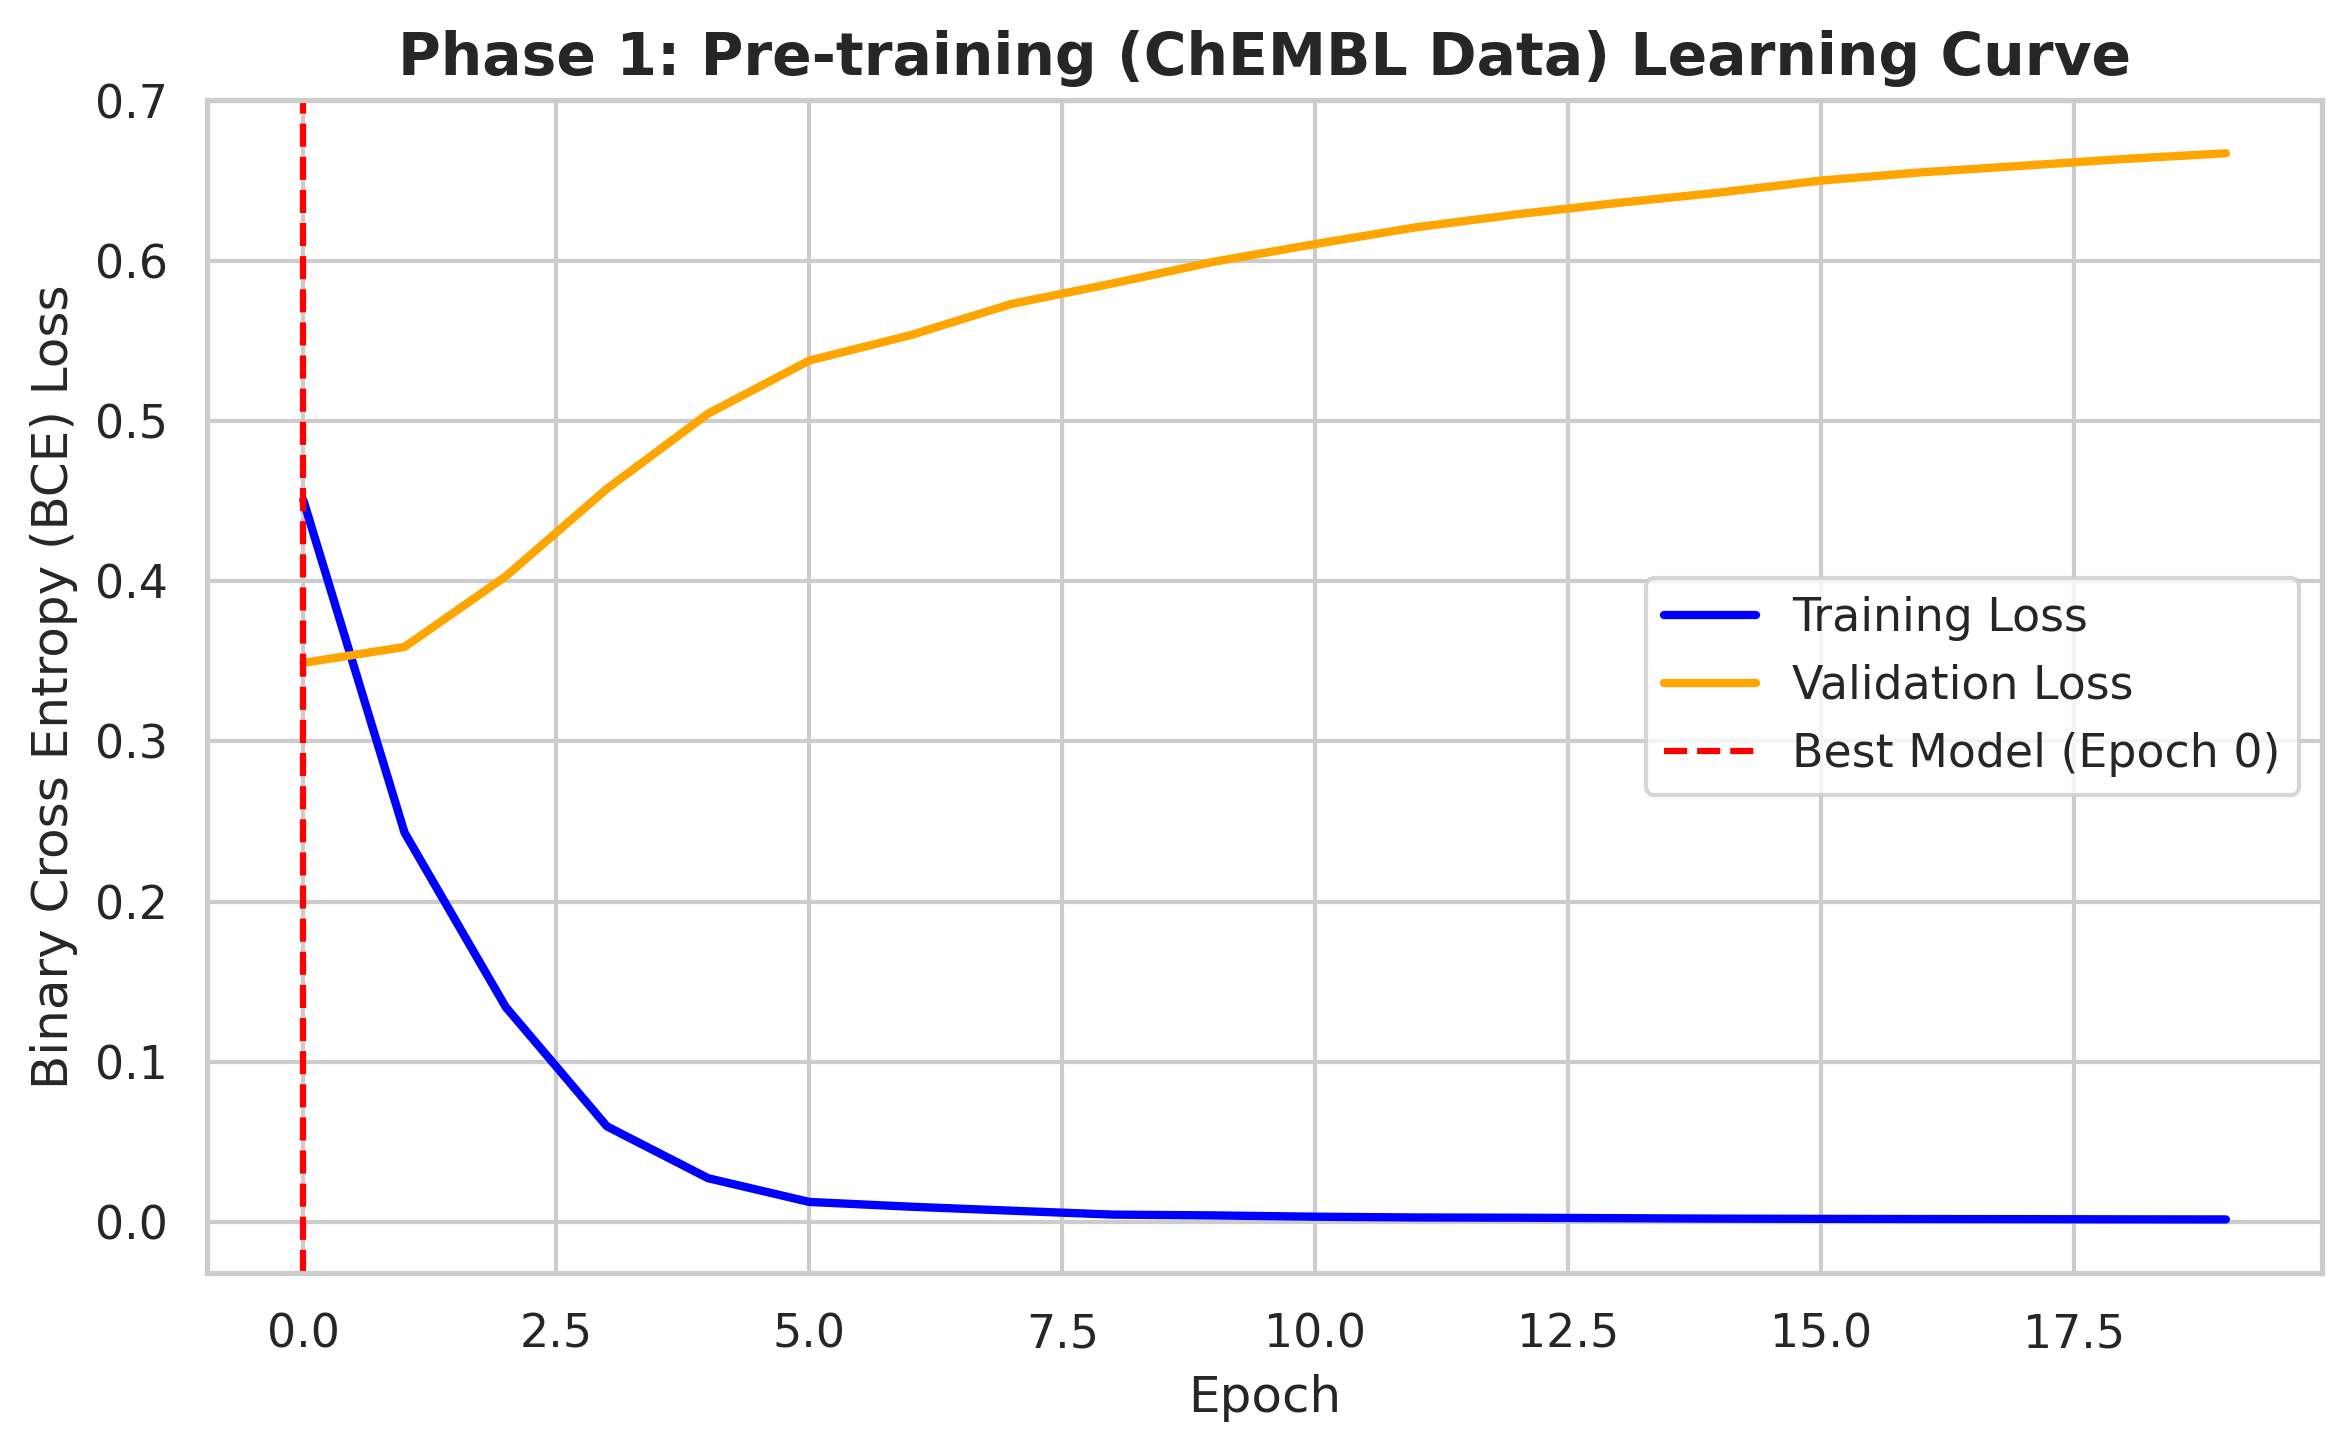

--- Phase 2: Fine-Tuning (H. pylori Data) ---
Best Validation Loss: 0.4707 (Achieved at Epoch 2)


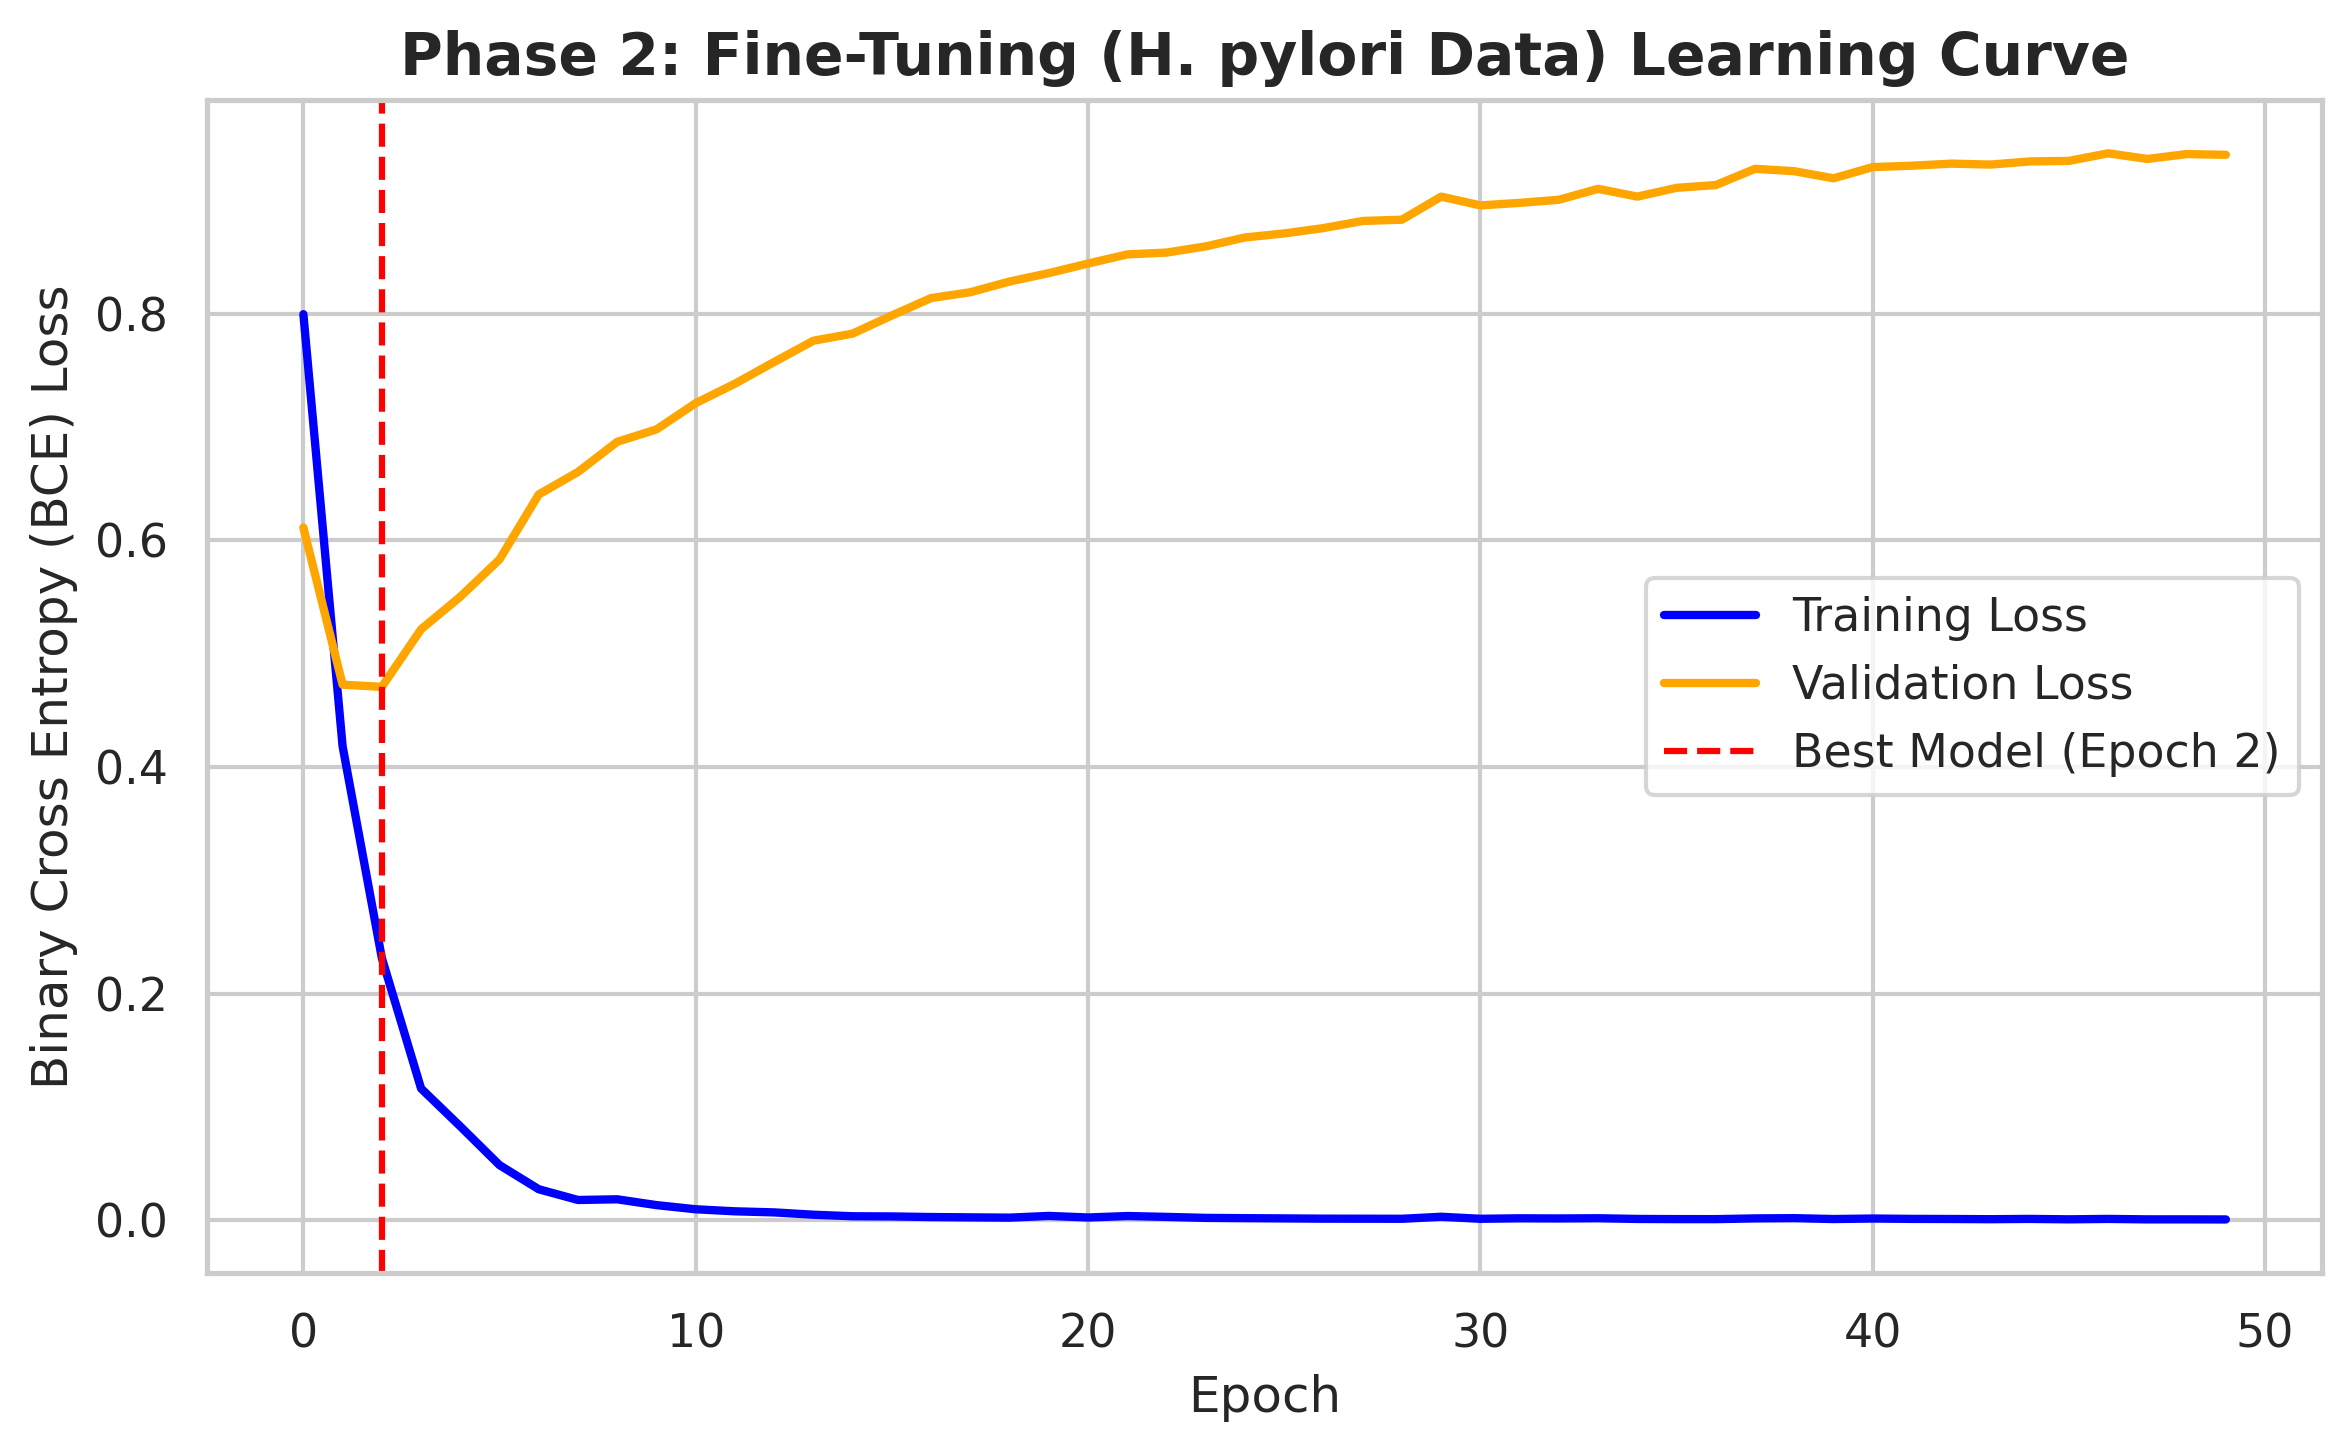

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting style
sns.set_theme(style="whitegrid")

def plot_learning_curve(metrics_path, title, save_filename):
    """Reads Lightning metrics.csv and plots Train vs Val Loss."""
    path = Path(metrics_path)
    if not path.exists():
        print(f"Could not find {metrics_path}")
        return

    # Load metrics
    df = pd.read_csv(path)
    
    # PyTorch Lightning saves val_loss and train_loss on different steps.
    # Grouping by epoch and taking the mean aligns them perfectly.
    epoch_metrics = df.groupby('epoch').mean()
    
    # Check if the necessary columns exist
    if 'val_loss' not in epoch_metrics.columns or 'train_loss_epoch' not in epoch_metrics.columns:
        print(f"Missing loss columns in {metrics_path}")
        return

    # Extract best validation loss
    best_epoch = epoch_metrics['val_loss'].idxmin()
    best_val_loss = epoch_metrics['val_loss'].min()
    
    print(f"--- {title} ---")
    print(f"Best Validation Loss: {best_val_loss:.4f} (Achieved at Epoch {int(best_epoch)})")
    
    # Plotting
    plt.figure(figsize=(8, 5), dpi=300)
    plt.plot(epoch_metrics.index, epoch_metrics['train_loss_epoch'], label='Training Loss', color='blue', linewidth=2)
    plt.plot(epoch_metrics.index, epoch_metrics['val_loss'], label='Validation Loss', color='orange', linewidth=2)
    
    # Mark the best epoch (where the checkpoint was saved)
    plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Model (Epoch {int(best_epoch)})')
    
    plt.title(f"{title} Learning Curve", fontsize=14, fontweight='bold')
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Binary Cross Entropy (BCE) Loss", fontsize=12)
    plt.legend(fontsize=11)
    
    plt.tight_layout()
    plt.savefig(save_filename)
    plt.show()

# 1. Plot Phase 1: Pre-training
plot_learning_curve(
    metrics_path="pretrain_model/model_0/trainer_logs/version_0/metrics.csv",
    title="Phase 1: Pre-training (ChEMBL Data)",
    save_filename="pretrain_learning_curve.png"
)

# 2. Plot Phase 2: Fine-Tuning
plot_learning_curve(
    metrics_path="finetune_model_improved/model_0/trainer_logs/version_0/metrics.csv",
    title="Phase 2: Fine-Tuning (H. pylori Data)",
    save_filename="finetune_learning_curve.png"
)